# Principal component analysis on bridge vibration data

Imagine to have accelerometers installed on a bridge. The structure vibrates under traffic and wind loads. Measurements from multiple sensors are correlated because all sensors are observing the same underlying structural modes. An example of such a dataset is provided by the "Bridge vibration monitoring dataset", DOI:10.17632/d3by55pjh7.2.

Vibration tests were conducted on a steel truss bridge using five uniaxial accelerometers under various traffic conditions. The accelerometers were connected to a data acquisition system, from which the data were transferred to a computer. Considering the flexibility of this bridge, a sampling frequency of 200Hz was used. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Load data 

In [2]:
file_path = "../Data/Bridge_vibrations/test1.txt" # Rows → time index; columns → sensor channel
data = pd.read_csv(file_path, sep="\t", skiprows=9, header=None) # Skip the first 9 text rows
X = data.values[:,1:-1] # Remove the first column (time) and the last empty column
print(X.shape)

(11137, 5)


### Visualize the five recordings for the test

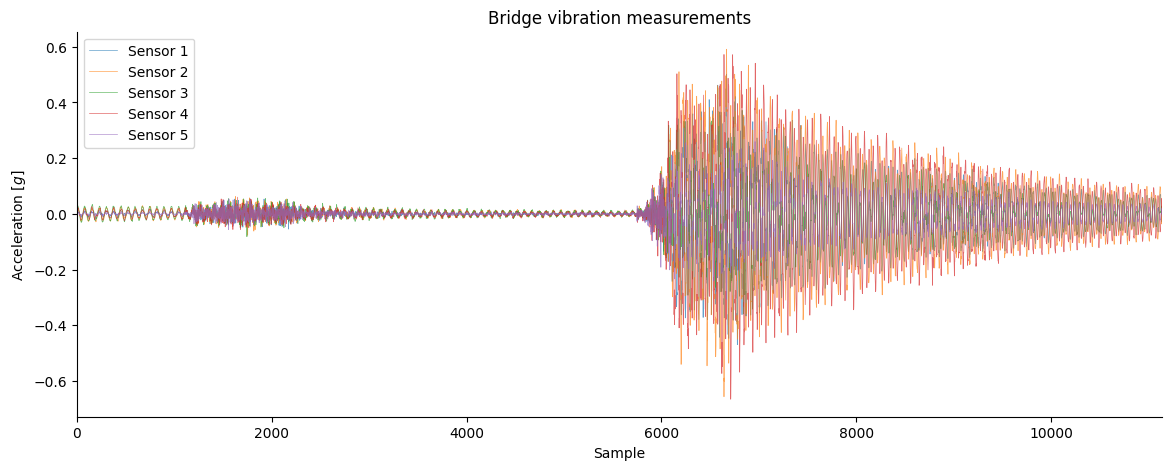

In [3]:
plt.figure(figsize=(14,5))

for i in range(X.shape[1]):
    plt.plot(X[:,i], alpha=0.7, linewidth=0.5, label=f"Sensor {i+1}")

plt.xlabel("Sample")
plt.ylabel("Acceleration $[g]$")
plt.title("Bridge vibration measurements")

plt.legend(loc='upper left')
plt.xlim([0,X.shape[0]])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

We can immediately recognize:

- Common frequencies
- Similar amplitudes
- Correlated behavior

PCA can therefore be used to:

- Identify dominant vibration patterns (modes)
- Reduce the dimensionality of the sensor data
- Filter measurement noise

### Data normalization

In [4]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

### Principal components computation and dimensionality reduction

In [5]:
pca = PCA()
Z = pca.fit_transform(X_std)

### Explained variance

PC1: 81.27%
PC2: 11.52%
PC3: 4.62%
PC4: 1.46%
PC5: 1.12%


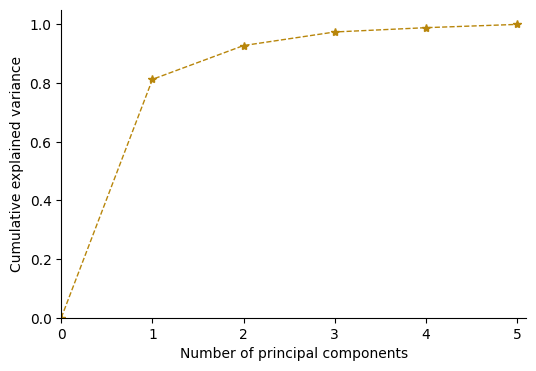

In [6]:
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {100*v:.2f}%")

# Cumulative explained variance ratio for increasing retained principal components
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))

plt.plot(np.arange(0,len(cum_var)+1),
        np.append(0,cum_var),
        marker="*", color='darkgoldenrod', linewidth=1, linestyle='--')

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")

plt.ylim(0, 1.05)
plt.xlim(0, 5.1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Although 5 sensors are present, the first principal component alone explains most of the variance; the first two principal components together explain more than 90\% of the variance. Indeed, the observed dynamics is generated by only a few dominant modes: each principal component can be seen as a spatial vibration pattern, analogous to a mode shape.

### Visualize the time evolution of the first two principal component coordinates

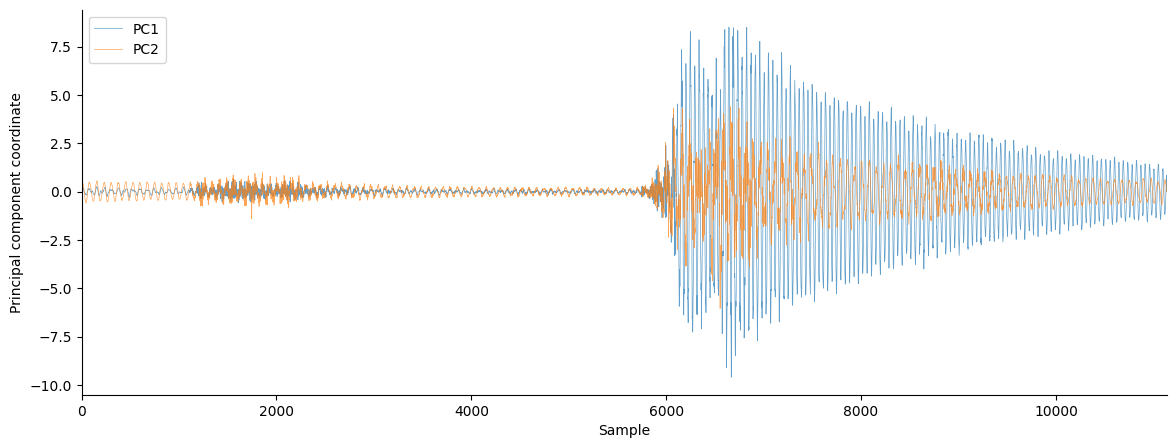

In [7]:
plt.figure(figsize=(14,5))

for i in range(2):
    plt.plot(Z[:,i], alpha=0.7, linewidth=0.5, label=f"PC{i+1}")

plt.xlabel("Sample")
plt.ylabel("Principal component coordinate")

plt.legend(loc='upper left')
plt.xlim([0,X.shape[0]])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### Low-rank reconstruction retaining only the first two principal components

We can now demonstrate the existence of an underlying low-dimensional structure, learned via PCA, that captures the structural behavior recorded by the five sensors. Specifically, we compress the five sensor recordings into a low-dimensional space spanned by the first two principal components. The original data can then be approximately reconstructed from this low-dimensional representation by projecting them back into the original high-dimensional space.

In [8]:
M = 2
pca_red = PCA(n_components=M)
Z_red = pca_red.fit_transform(X_std) # Dimensionality reduction
X_rec = pca_red.inverse_transform(Z_red) # Back projection

### Compare reconstructed and original signals

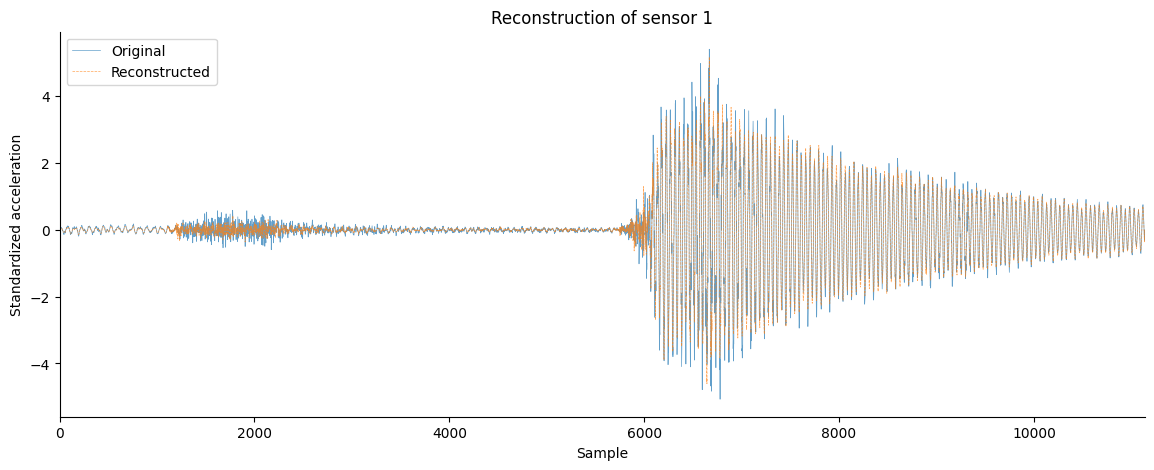

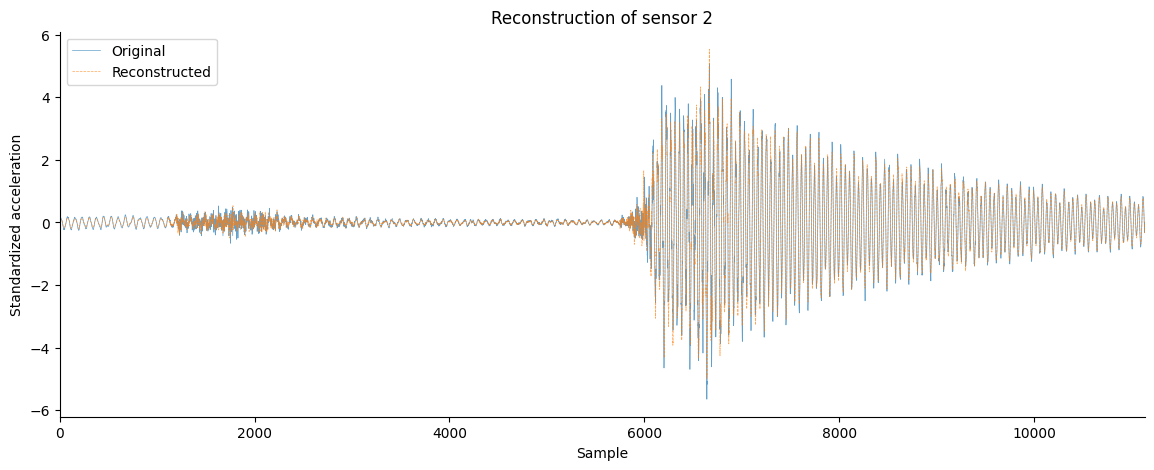

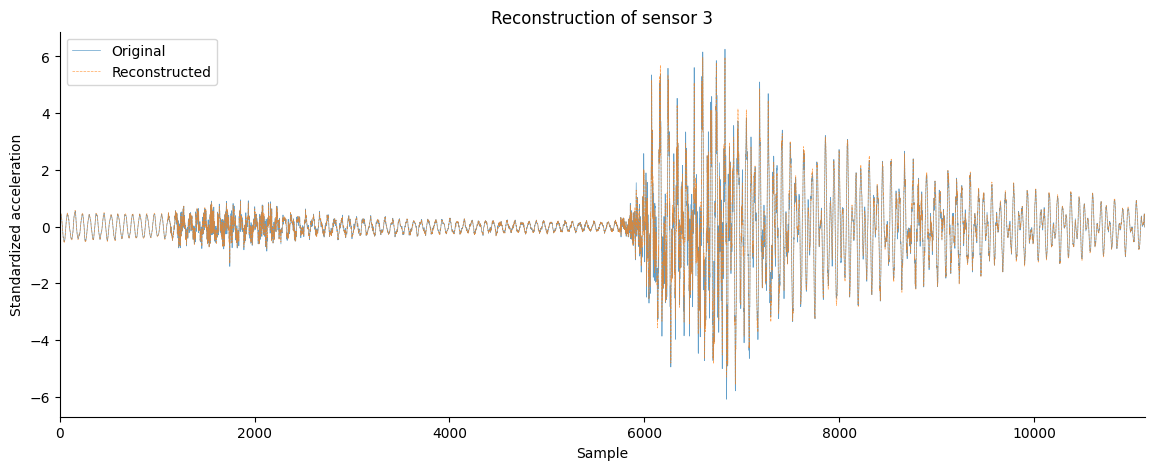

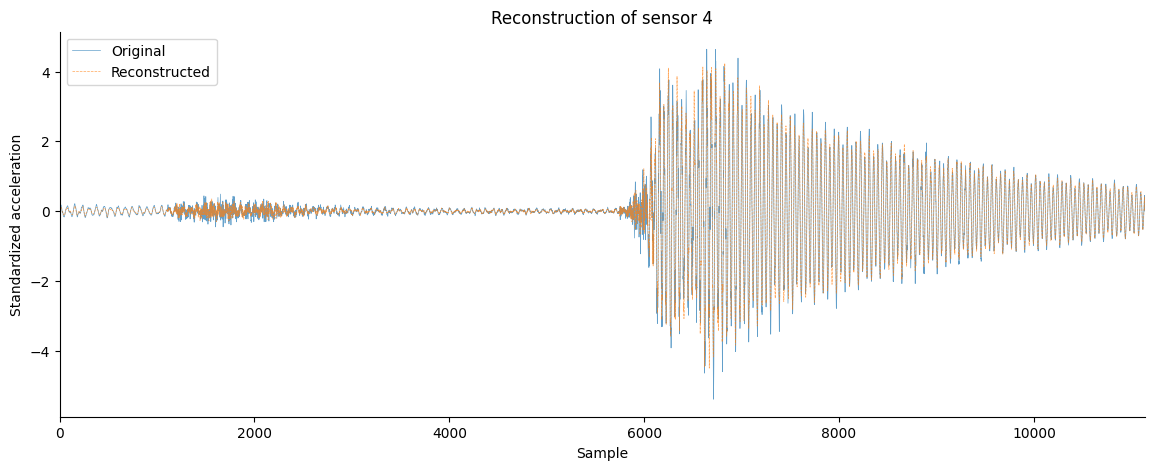

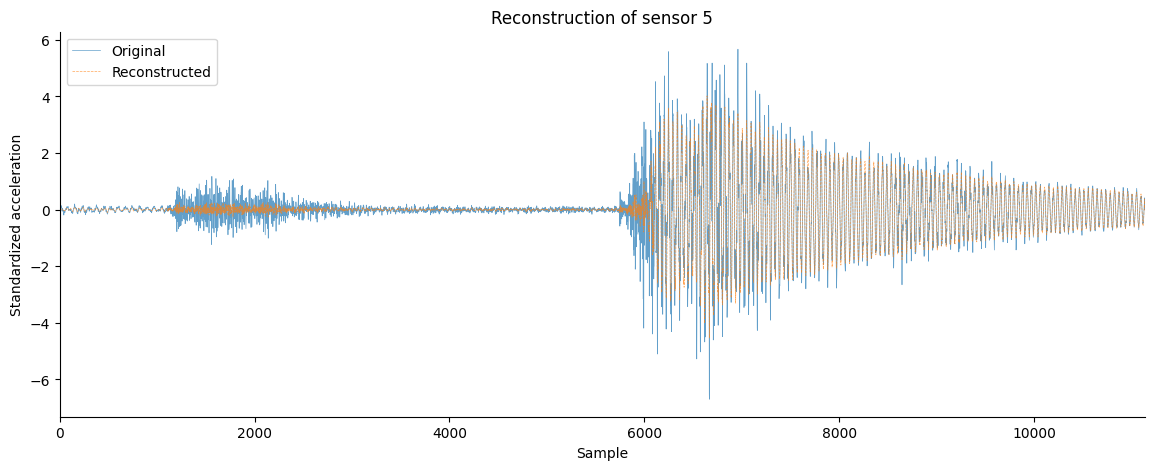

In [9]:
for i in range(X.shape[1]):

    plt.figure(figsize=(14,5))
    
    plt.plot(X_std[:,i],
            label="Original", alpha=0.7, linewidth=0.5,)
    
    plt.plot(X_rec[:,i],
            "--", label="Reconstructed", alpha=0.7, linewidth=0.5)
    
    plt.xlabel("Sample")
    plt.ylabel("Standardized acceleration")
    
    plt.legend(loc='upper left')
    plt.xlim([0,X.shape[0]])
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.title(f"Reconstruction of sensor {i+1}")
    
    plt.show()